In [ ]:
!pip install -q transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.9 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "meta-llama/Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

First for sentiment classification

In [ ]:
def generate_label(system_prompt, user_prompt, max_new_tokens=20):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]


    tokenized_chat = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)


    input_ids = tokenized_chat['input_ids']
    attention_mask = tokenized_chat['attention_mask']

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )


    response = tokenizer.decode(
        outputs[0][input_ids.shape[-1]:],
        skip_special_tokens=True
    ).strip()

    return response

In [ ]:
sentiment_system_prompt = """
You are a text classification assistant.
Read the review and output exactly one label from:
positive, neutral, negative

Do not explain.
Do not add punctuation.
Output only the label.
""".strip()

In [ ]:
import pandas as pd

sent_df = pd.read_csv("/content/sentiment_real_reviews_1000.csv")
sent_df = sent_df[["reviews", "sentiment_label"]].dropna()

print(sent_df.head())
print(sent_df["sentiment_label"].value_counts())

                                             reviews sentiment_label
0  Lol.... the only reason i bought this tablet w...        negative
1  Wish tablet was voice capable. Only problem wa...        negative
2  Alexa works great with music. Just wish you di...        positive
3  Led to more echo dots and significant home aut...         neutral
4  I purchased this after trying the Insignia 8" ...        positive
sentiment_label
negative    334
positive    333
neutral     333
Name: count, dtype: int64


In [ ]:
sample_reviews = [
    "This product is excellent and works perfectly. I am very happy with it.",
    "The item is okay. Not bad, but nothing special.",
    "Very disappointing product. It stopped working after two days."
]

for review in sample_reviews:
    pred = generate_label(
        sentiment_system_prompt,
        f"Review: {review}"
    )
    print("Review:", review)
    print("Predicted sentiment:", pred)
    print("-" * 60)

Review: This product is excellent and works perfectly. I am very happy with it.
Predicted sentiment: positive
------------------------------------------------------------
Review: The item is okay. Not bad, but nothing special.
Predicted sentiment: neutral
------------------------------------------------------------
Review: Very disappointing product. It stopped working after two days.
Predicted sentiment: negative
------------------------------------------------------------


In [ ]:
sentiment_predictions = []

for review in sent_df["reviews"]:
    pred = generate_label(
        sentiment_system_prompt,
        f"Review: {review}"
    ).lower().strip()
    sentiment_predictions.append(pred)

sent_df["predicted_sentiment"] = sentiment_predictions

In [ ]:
valid_sentiment_labels = {"positive", "neutral", "negative"}

def clean_sentiment_label(x):
    x = str(x).lower().strip()
    if "positive" in x:
        return "positive"
    elif "neutral" in x:
        return "neutral"
    elif "negative" in x:
        return "negative"
    return "unknown"

sent_df["predicted_sentiment"] = sent_df["predicted_sentiment"].apply(clean_sentiment_label)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(sent_df["sentiment_label"], sent_df["predicted_sentiment"]))
print("\nClassification Report:\n")
print(classification_report(sent_df["sentiment_label"], sent_df["predicted_sentiment"]))
print("\nConfusion Matrix:\n")
print(confusion_matrix(sent_df["sentiment_label"], sent_df["predicted_sentiment"]))

Accuracy: 0.491

Classification Report:

              precision    recall  f1-score   support

    negative       0.80      0.38      0.52       334
     neutral       0.34      0.16      0.21       333
    positive       0.45      0.93      0.61       333

    accuracy                           0.49      1000
   macro avg       0.53      0.49      0.45      1000
weighted avg       0.53      0.49      0.45      1000


Confusion Matrix:

[[128  87 119]
 [ 26  52 255]
 [  7  15 311]]


Now Checking on sarcasm dataset

In [ ]:
sarcasm_system_prompt = """
You are a sarcasm detection assistant.
Read the product review and output exactly one label from:
sarcastic, standard

'sarcastic' means the review uses irony, contradiction, or implied meaning.
'standard' means the review is literal and non-sarcastic.

Do not explain.
Do not add punctuation.
Output only the label.
""".strip()

In [ ]:
sar_df = pd.read_csv("/content/sarcasm_mixed_reviews_1000.csv")
sar_df = sar_df[["reviews", "style"]].dropna()

print(sar_df.head())
print(sar_df["style"].value_counts())

                                             reviews      style
0  What an annoying outcome: the tablet actually ...  sarcastic
1  So many products on the market. This by far is...   standard
2  Really easy to work with lots of extras. Good ...   standard
3  A stunning display of modern engineering — thi...  sarcastic
4  Ever since I had my fire TV jail broken and pr...   standard
style
sarcastic    500
standard     500
Name: count, dtype: int64


In [ ]:
sample_reviews = [
    "This product is fantastic and works perfectly.",
    "Wow, amazing charger. It stopped working in one day.",
    "Absolutely brilliant. I love how it stopped working immediately.",
    "The product is average, not too bad and not too good.",
    "disappointing charger. I thought it would stop working in one day, but is working absolutely fine."
]

for review in sample_reviews:
    pred = generate_label(
        sarcasm_system_prompt,
        f"Review: {review}"
    )
    print("Review:", review)
    print("Predicted style:", pred)
    print("-" * 60)

Review: This product is fantastic and works perfectly.
Predicted style: standard
------------------------------------------------------------
Review: Wow, amazing charger. It stopped working in one day.
Predicted style: sarcastic
------------------------------------------------------------
Review: Absolutely brilliant. I love how it stopped working immediately.
Predicted style: sarcastic
------------------------------------------------------------
Review: The product is average, not too bad and not too good.
Predicted style: standard
------------------------------------------------------------
Review: disappointing charger. I thought it would stop working in one day, but is working absolutely fine.
Predicted style: sarcastic
------------------------------------------------------------


In [ ]:
sarcasm_predictions = []

for review in sar_df["reviews"]:
    pred = generate_label(
        sarcasm_system_prompt,
        f"Review: {review}"
    ).lower().strip()
    sarcasm_predictions.append(pred)

sar_df["predicted_style"] = sarcasm_predictions

In [ ]:
valid_sarcasm_labels = {"sarcastic", "standard"}

def clean_sarcasm_label(x):
    x = str(x).lower().strip()
    if "sarcastic" in x:
        return "sarcastic"
    elif "standard" in x:
        return "standard"
    return "unknown"

sar_df["predicted_style"] = sar_df["predicted_style"].apply(clean_sarcasm_label)

In [ ]:
print("Accuracy:", accuracy_score(sar_df["style"], sar_df["predicted_style"]))
print("\nClassification Report:\n")
print(classification_report(sar_df["style"], sar_df["predicted_style"]))
print("\nConfusion Matrix:\n")
print(confusion_matrix(sar_df["style"], sar_df["predicted_style"]))

Accuracy: 0.699

Classification Report:

              precision    recall  f1-score   support

   sarcastic       0.63      0.98      0.77       500
    standard       0.96      0.42      0.58       500

    accuracy                           0.70      1000
   macro avg       0.79      0.70      0.67      1000
weighted avg       0.79      0.70      0.67      1000


Confusion Matrix:

[[491   9]
 [292 208]]


In [ ]:
sent_df.to_csv("/content/llama_sentiment_predictions.csv", index=False)
sar_df.to_csv("/content/llama_sarcasm_predictions.csv", index=False)

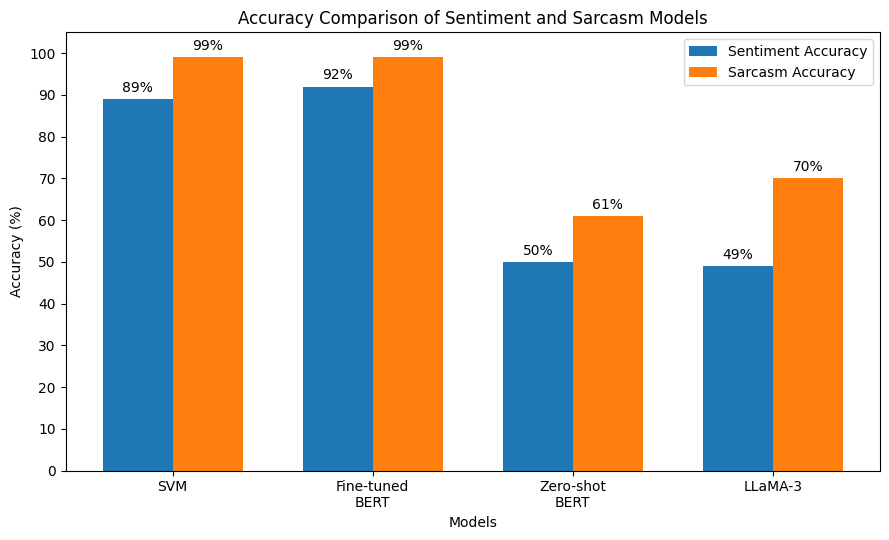

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ["SVM", "Fine-tuned\nBERT", "Zero-shot\nBERT", "LLaMA-3"]

sentiment_accuracy = [89, 92, 50, 49]
sarcasm_accuracy = [99, 99, 61, 70]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5.5))

bars1 = plt.bar(
    x - width/2,
    sentiment_accuracy,
    width,
    label="Sentiment Accuracy"
)

bars2 = plt.bar(
    x + width/2,
    sarcasm_accuracy,
    width,
    label="Sarcasm Accuracy"
)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Sentiment and Sarcasm Models")
plt.xticks(x, models)
plt.yticks(np.arange(0, 101, 10))
plt.ylim(0, 105)
plt.legend()


for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()